In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
import requests
def load(url, names=None):
    filename = os.path.basename(url)
    response = requests.get(url)
    with open(filename, "wb") as f:
        f.write(response.content)
    df = pd.read_csv(filename, header=None, names=names)
    display(df.head())
    return df

In [1]:
df = load("https://files.0xarchit.is-a.dev/datasets/pca_data.csv")

NameError: name 'load' is not defined

In [2]:
display(df.head(5))

NameError: name 'df' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      214 non-null    int64  
 1   RI      214 non-null    float64
 2   Na      214 non-null    float64
 3   Mg      214 non-null    float64
 4   Al      214 non-null    float64
 5   Si      214 non-null    float64
 6   K       214 non-null    float64
 7   Ca      214 non-null    float64
 8   Ba      214 non-null    float64
 9   Fe      214 non-null    float64
 10  Type    214 non-null    int64  
dtypes: float64(9), int64(2)
memory usage: 18.5 KB


In [ ]:
df.describe()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,107.500000,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,61.920648,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.000000,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,54.250000,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,107.500000,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,160.750000,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,214.000000,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [ ]:
df.corr()

,Id,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
Id,1.000000,-0.072209,0.375722,-0.650328,0.490113,0.061232,0.003149,0.090800,0.451001,-0.072794,0.877357
RI,-0.072209,1.000000,-0.191885,-0.122274,-0.407326,-0.542052,-0.289833,0.810403,-0.000386,0.143010,-0.164237
Na,0.375722,-0.191885,1.000000,-0.273732,0.156794,-0.069809,-0.266087,-0.275442,0.326603,-0.241346,0.502898
Mg,-0.650328,-0.122274,-0.273732,1.000000,-0.481799,-0.165927,0.005396,-0.443750,-0.492262,0.083060,-0.744993
Al,0.490113,-0.407326,0.156794,-0.481799,1.000000,-0.005524,0.325958,-0.259592,0.479404,-0.074402,0.598829
Si,0.061232,-0.542052,-0.069809,-0.165927,-0.005524,1.000000,-0.193331,-0.208732,-0.102151,-0.094201,0.151565
K,0.003149,-0.289833,-0.266087,0.005396,0.325958,-0.193331,1.000000,-0.317836,-0.042618,-0.007719,-0.010054
Ca,0.090800,0.810403,-0.275442,-0.443750,-0.259592,-0.208732,-0.317836,1.000000,-0.112841,0.124968,0.000952
Ba,0.451001,-0.000386,0.326603,-0.492262,0.479404,-0.102151,-0.042618,-0.112841,1.000000,-0.058692,0.575161
Fe,-0.072794,0.143010,-0.241346,0.083060,-0.074402,-0.094201,-0.007719,0.124968,-0.058692,1.000000,-0.188278


<Axes: >

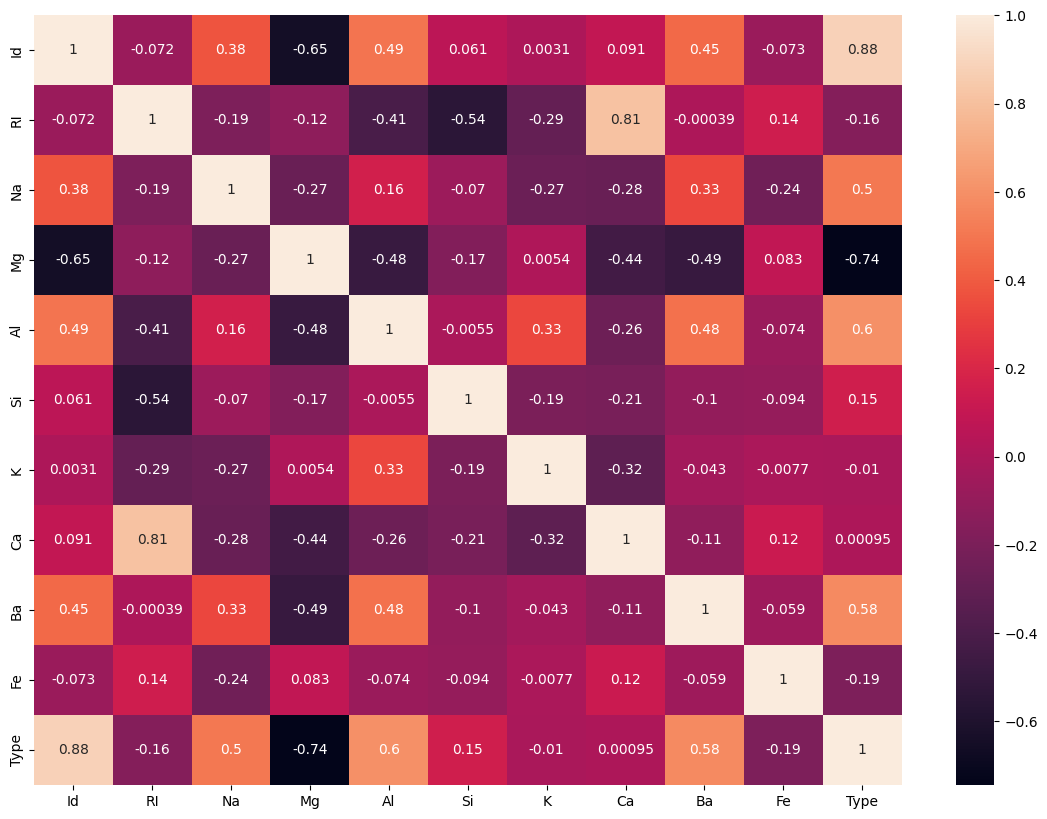

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True)

In [ ]:
df2 = df.drop('Id', axis=1)

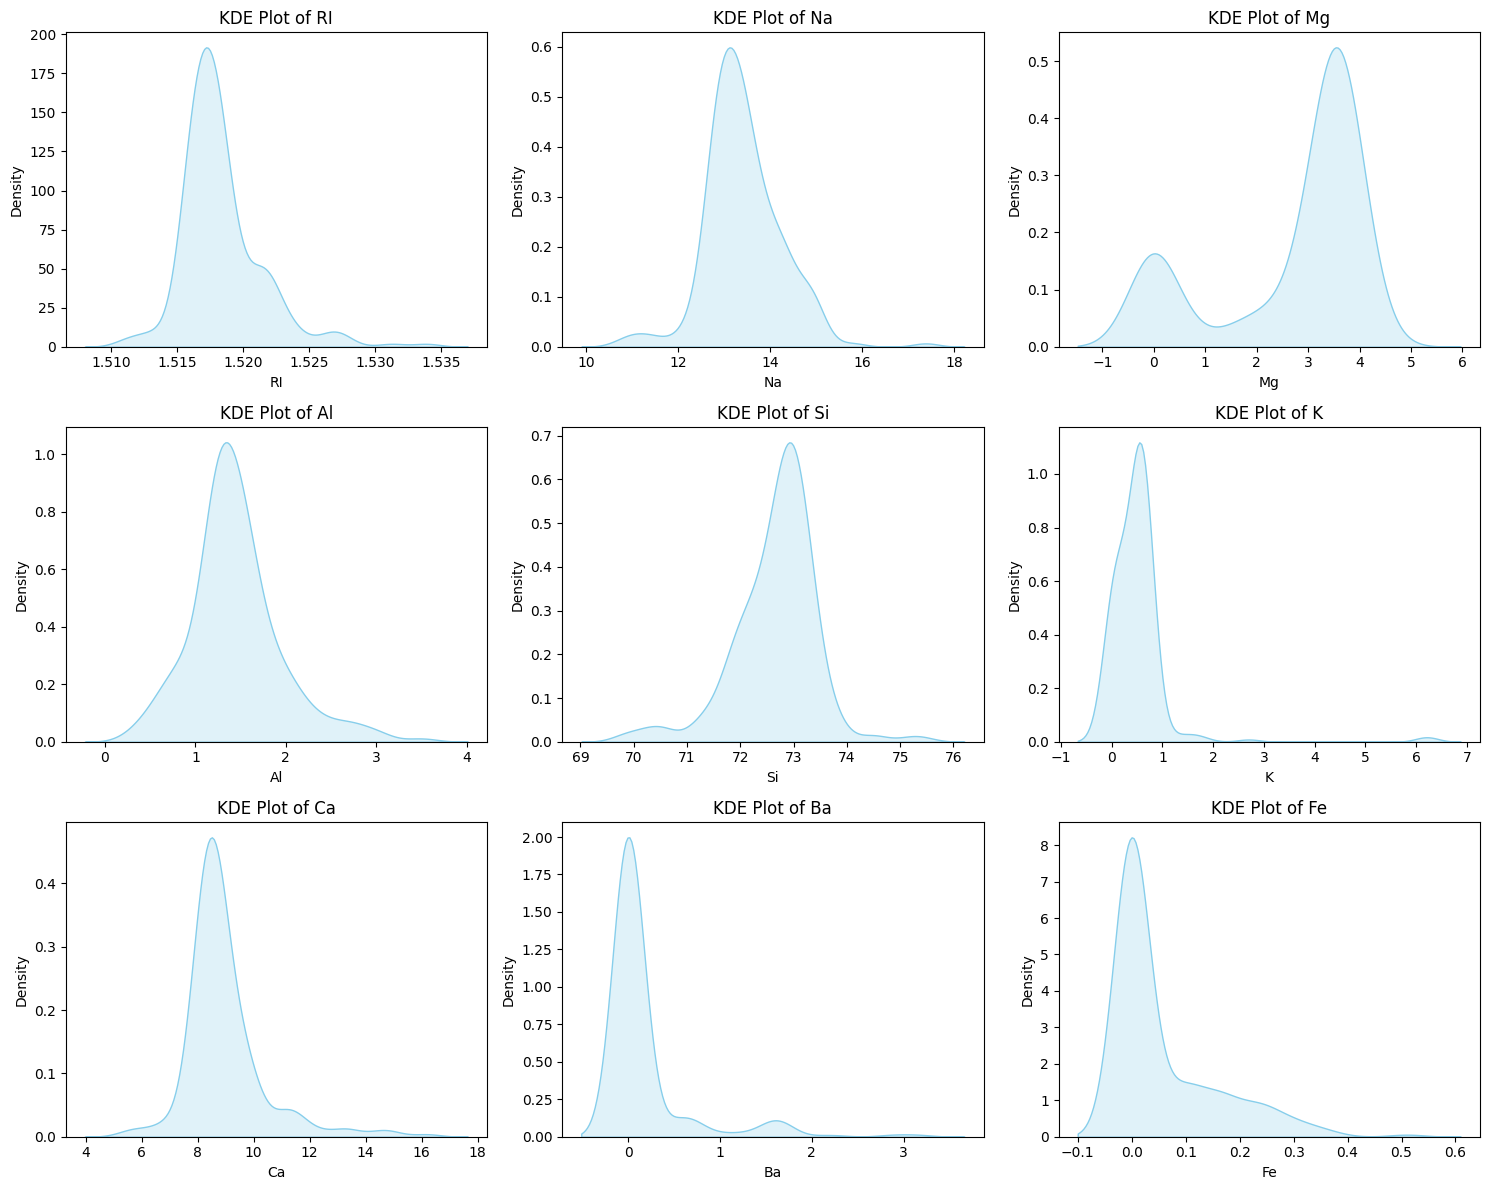

In [ ]:
features = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
num_cols = 3
num_rows = 3

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, feature in enumerate(features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.kdeplot(df2[feature], fill=True, color='skyblue')
    plt.title(f'KDE Plot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.tight_layout()

plt.show()

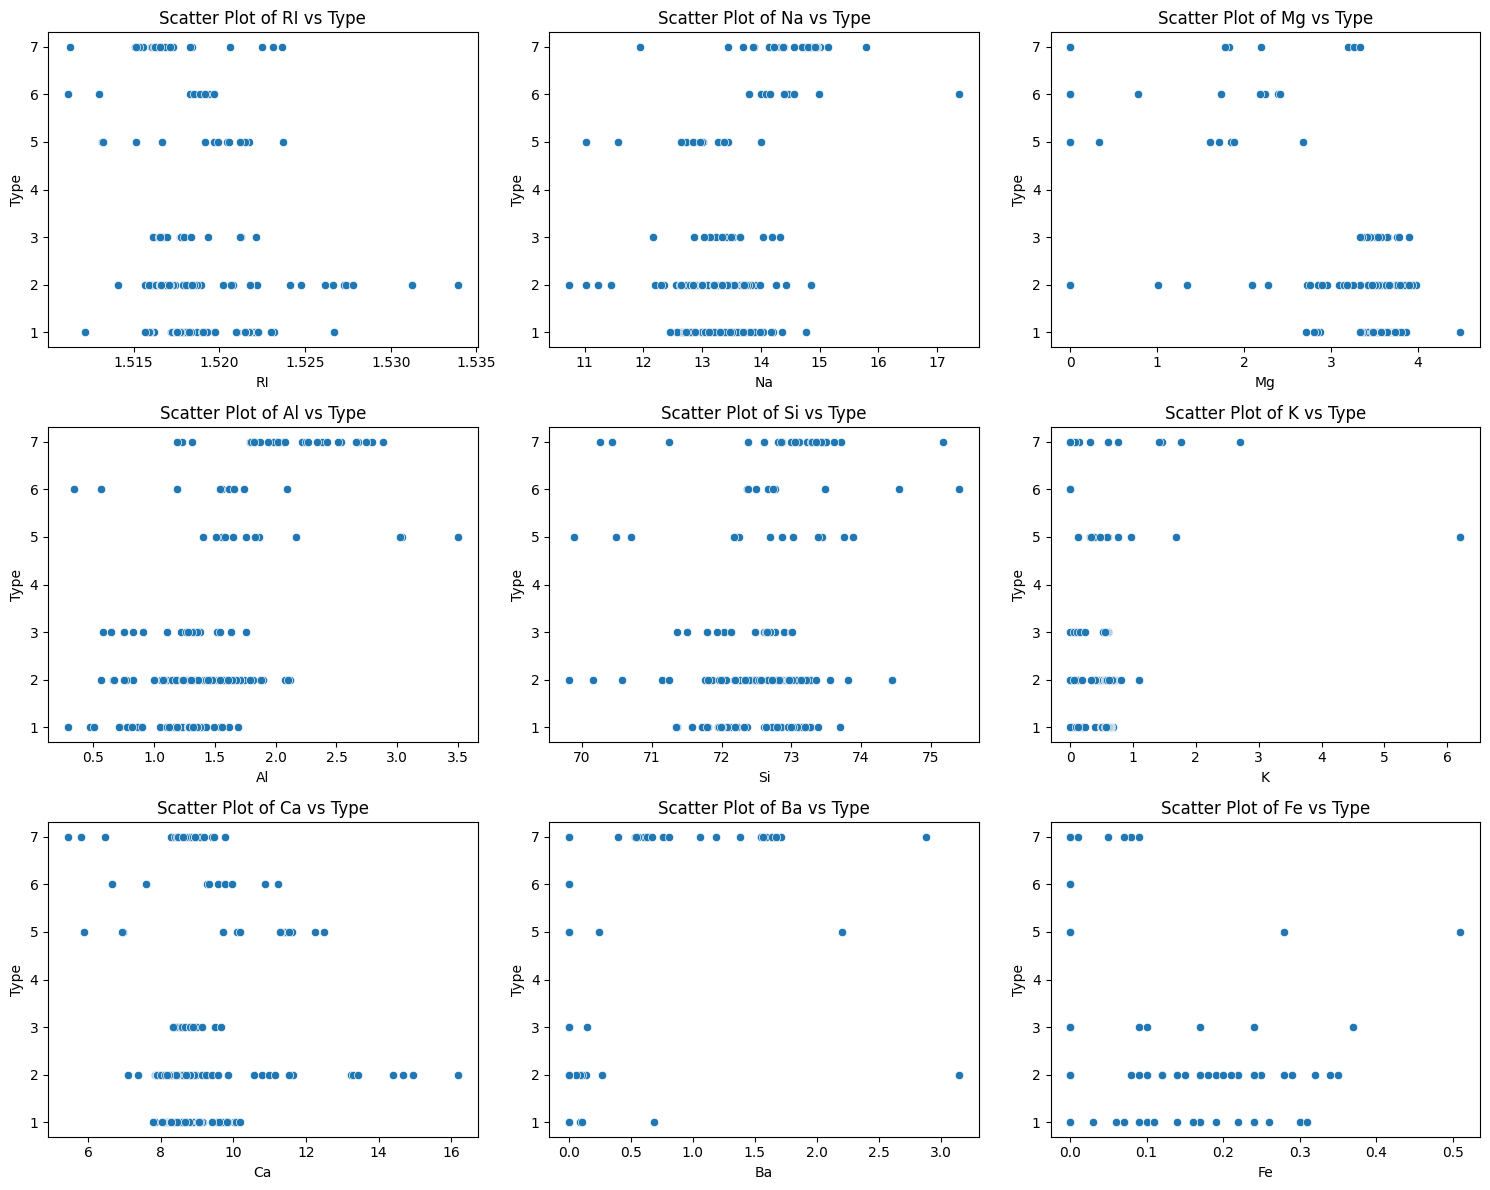

In [ ]:
plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, feature in enumerate(features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.scatterplot(x=df2[feature], y=df2['Type'])
    plt.title(f'Scatter Plot of {feature} vs Type')
    plt.xlabel(feature)
    plt.ylabel('Type')
    plt.tight_layout()

plt.show()

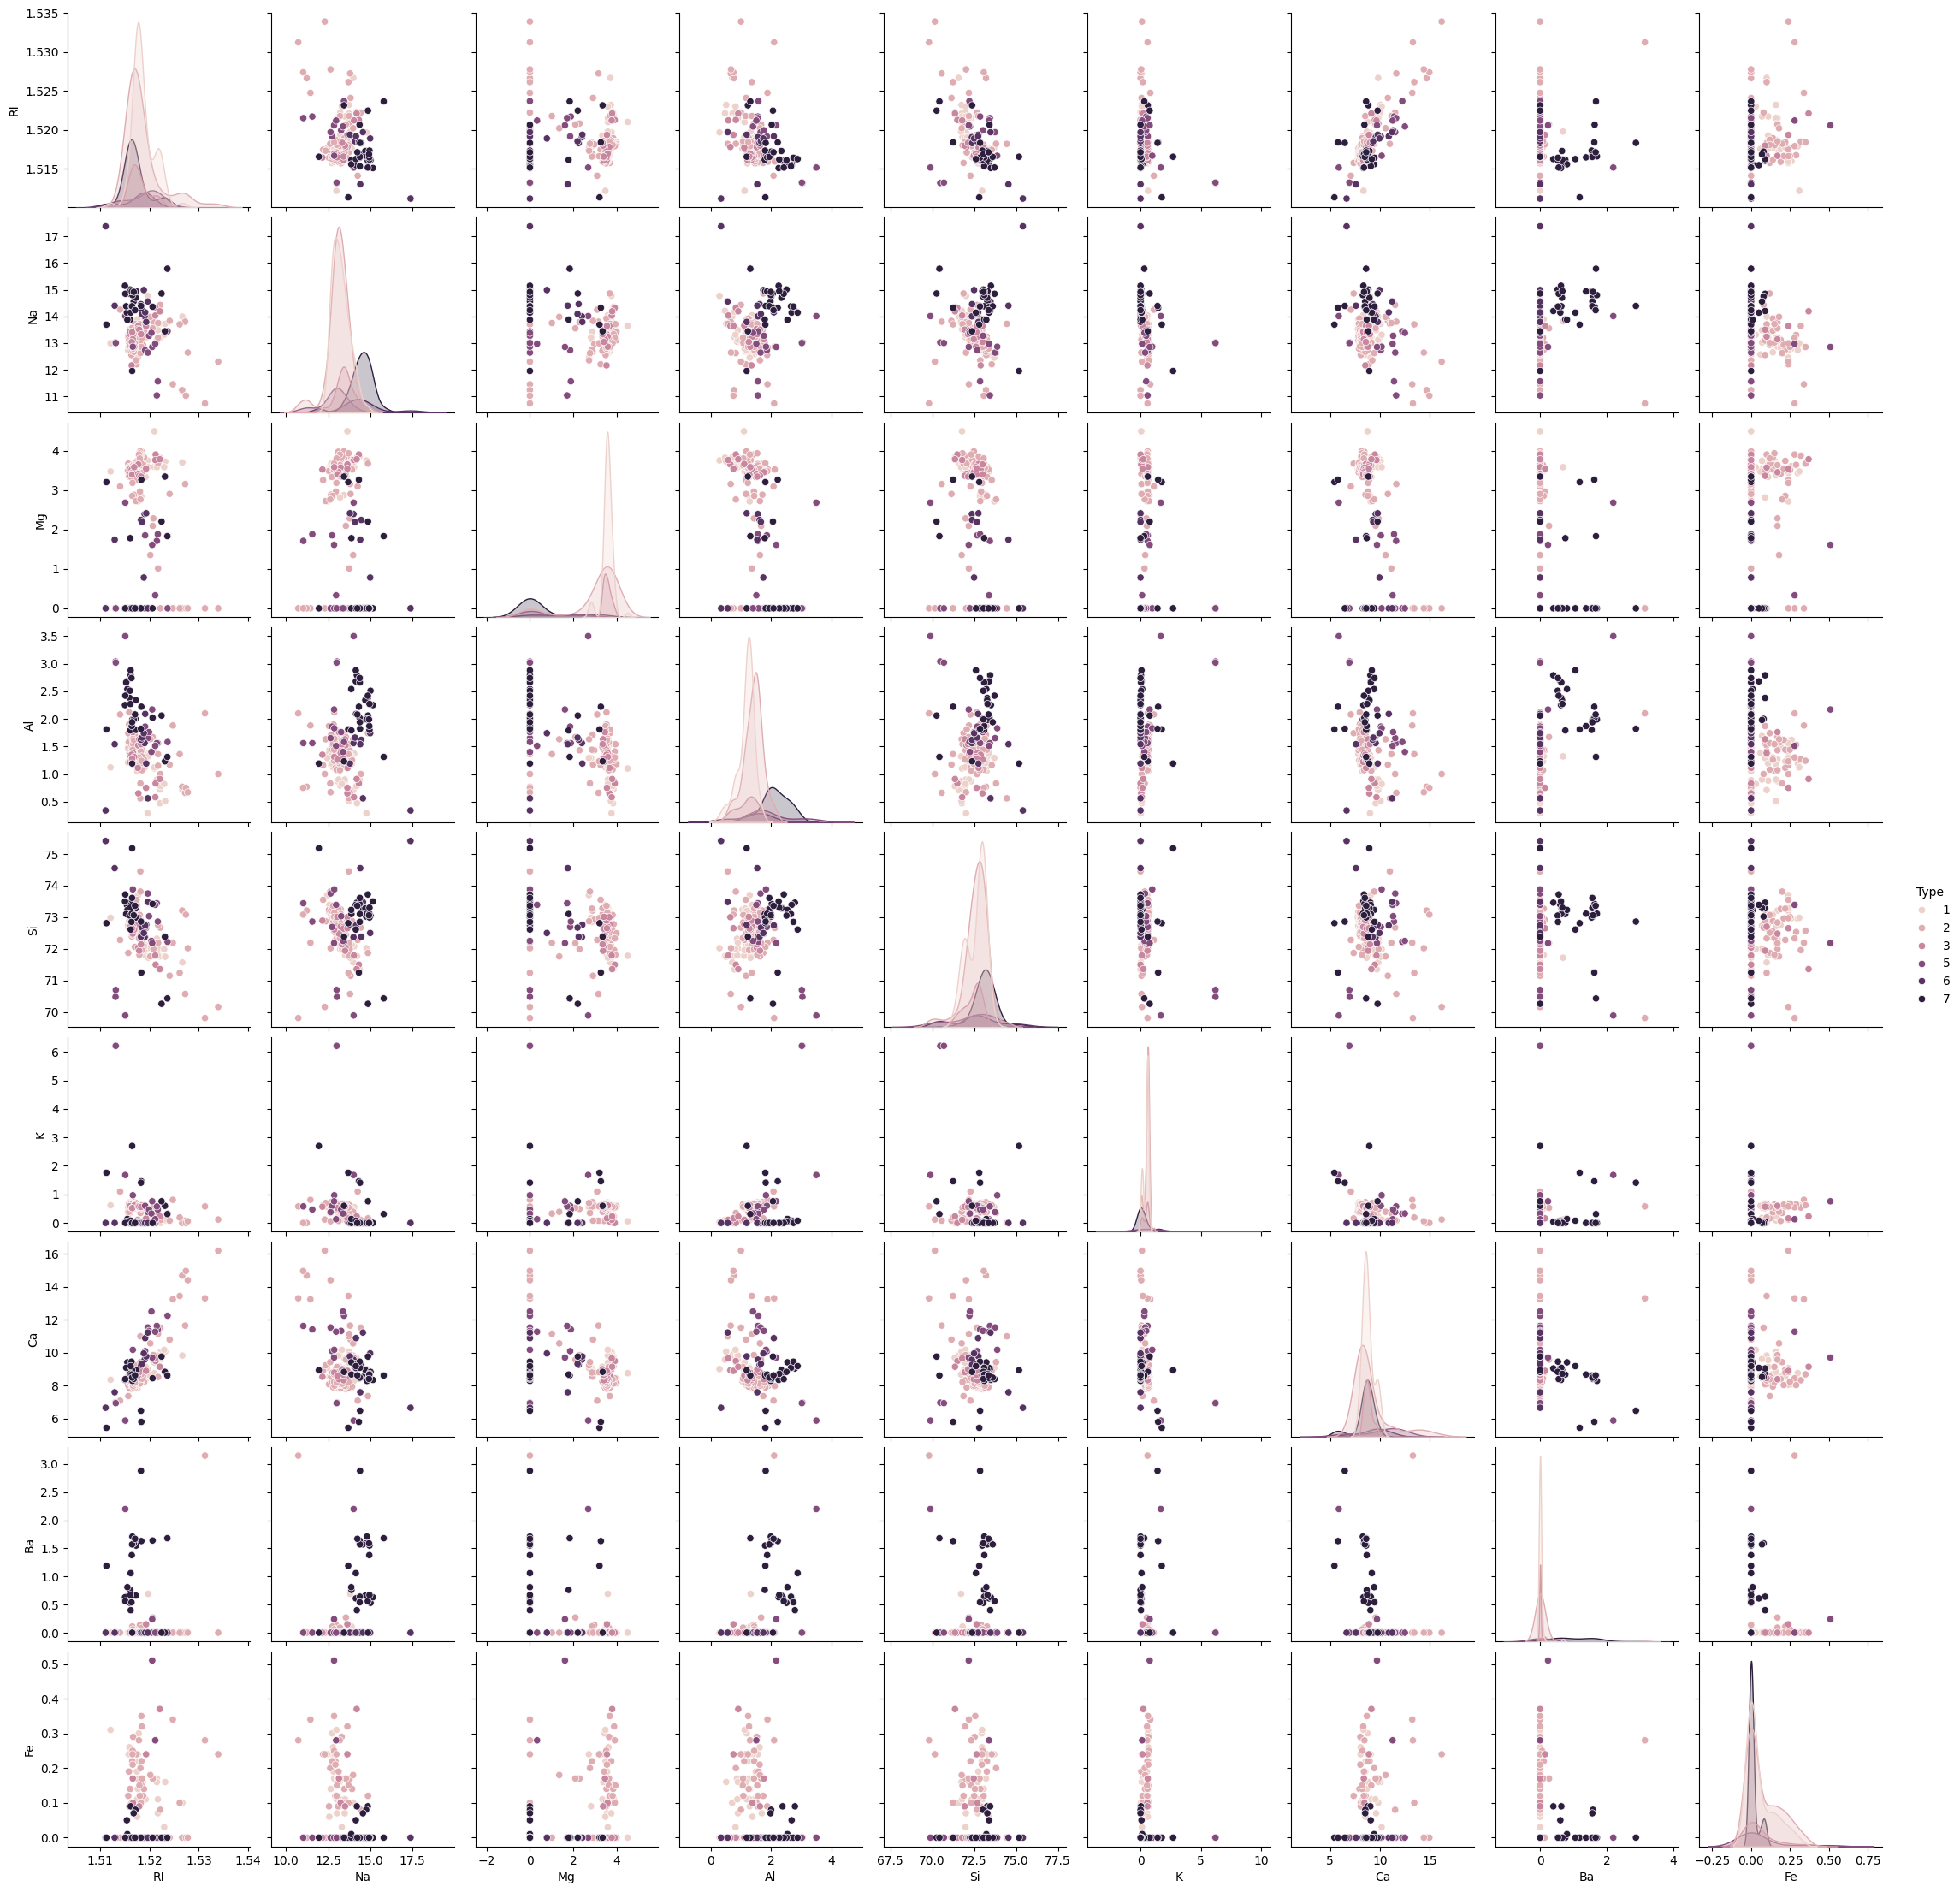

In [ ]:
sns.pairplot(df2, hue='Type')

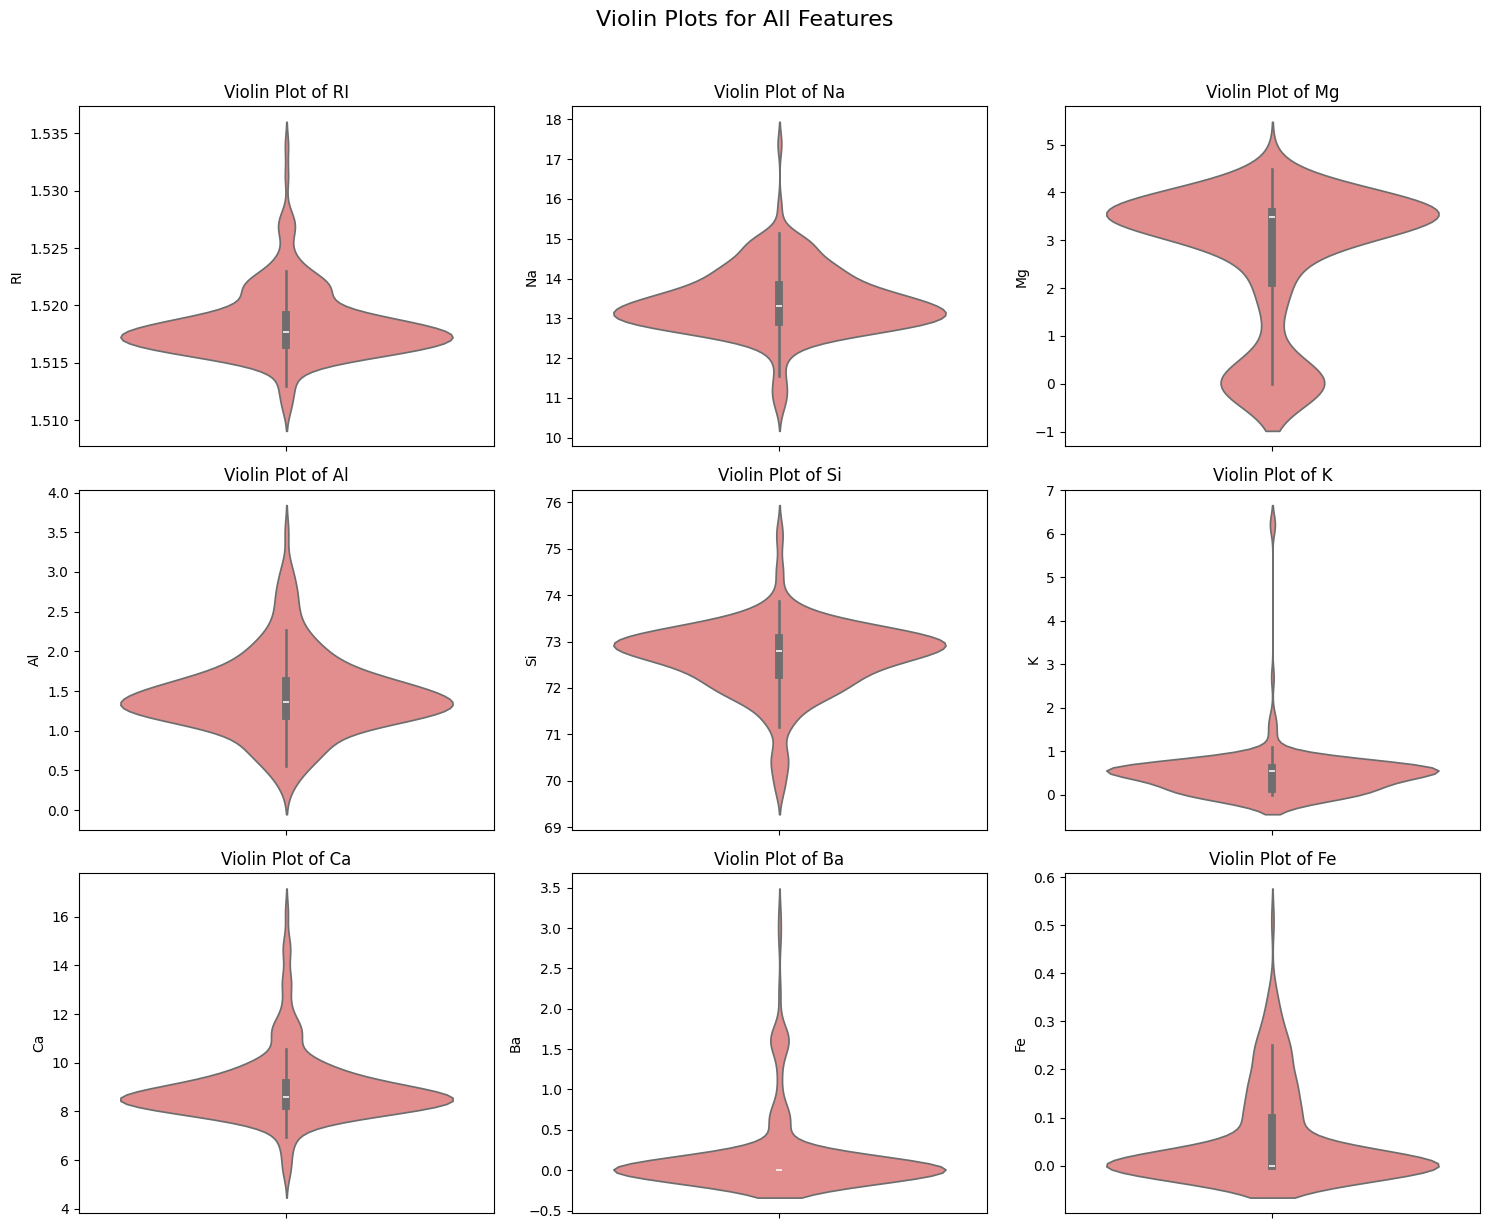

In [ ]:
plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('Violin Plots for All Features', y=1.02, fontsize=16)
for i, feature in enumerate(features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.violinplot(y=df2[feature], color='lightcoral')
    plt.title(f'Violin Plot of {feature}')
    plt.xlabel('')
    plt.ylabel(feature)
    plt.tight_layout()
plt.show()

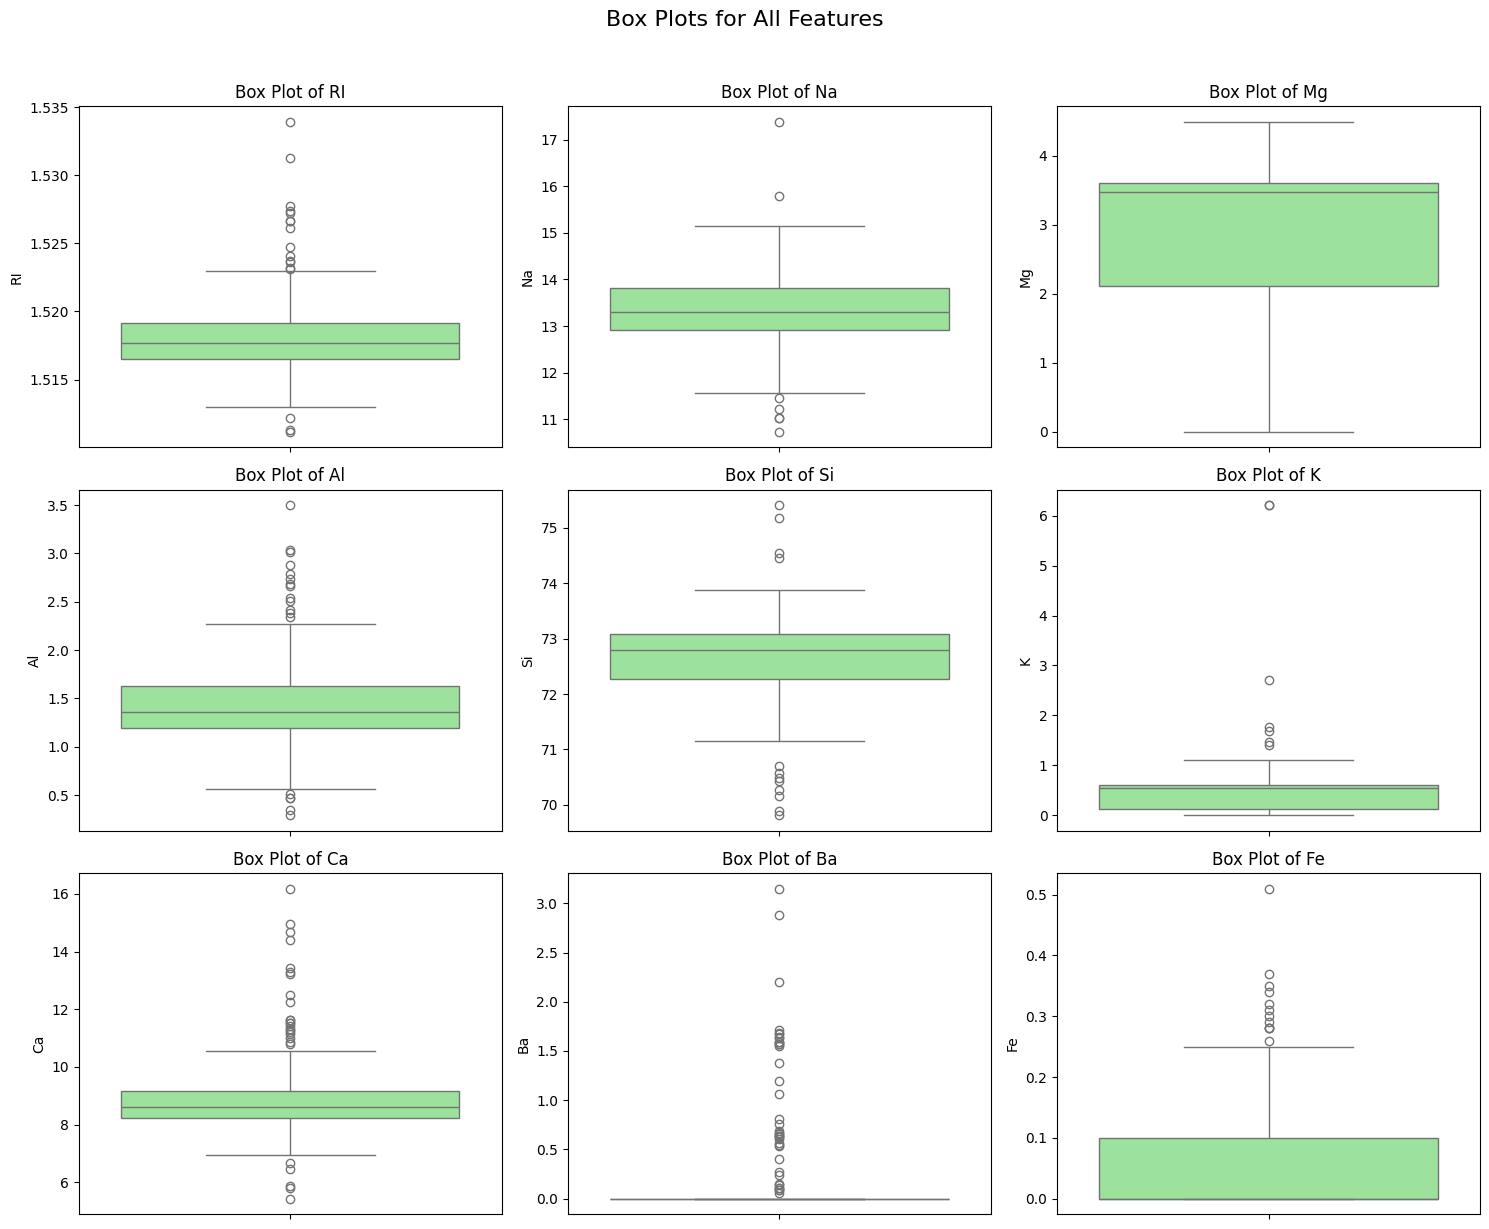

In [ ]:
plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('Box Plots for All Features', y=1.02, fontsize=16)
for i, feature in enumerate(features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=df2[feature], color='lightgreen')
    plt.title(f'Box Plot of {feature}')
    plt.xlabel('')
    plt.ylabel(feature)
    plt.tight_layout()
plt.show()

ba is outliers filled but it is useful for refractive index modification thats why we need to keep it


In [ ]:
# train test split
from sklearn.model_selection import train_test_split
X = df2.drop('Type', axis=1)
y = df2['Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# ensemble learning - voting, bagging,

In [ ]:
# decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_test, y_pred, average='weighted')

0.7886177130363176

In [ ]:
recall_score(y_test, y_pred, average='weighted')

0.7674418604651163

In [ ]:
f1_score(y_test, y_pred, average='weighted')

0.7496319458015764

In [ ]:
confusion_matrix(y_test, y_pred)

array([[10,  0,  0,  0,  0,  1],
       [ 4,  9,  1,  0,  0,  0],
       [ 0,  0,  3,  0,  0,  0],
       [ 0,  3,  0,  1,  0,  0],
       [ 0,  1,  0,  0,  2,  0],
       [ 0,  0,  0,  0,  0,  8]])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

precision = precision_score(y_test, y_pred_rf, average='weighted')
print(f"Precision: {precision}")

recall = recall_score(y_test, y_pred_rf, average='weighted')
print(f"Recall: {recall}")

f1 = f1_score(y_test, y_pred_rf, average='weighted')
print(f"F1-score: {f1}")

conf_matrix = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:")
print(conf_matrix)

Precision: 0.866828165374677
Recall: 0.8372093023255814
F1-score: 0.8330452594474481
Confusion Matrix:
[[11  0  0  0  0  0]
 [ 4  9  0  0  0  1]
 [ 1  0  2  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score

et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train, y_train)

y_pred_et = et_model.predict(X_test)

precision_et = precision_score(y_test, y_pred_et, average='weighted')
print(f"ExtraTrees Precision: {precision_et}")

recall_et = recall_score(y_test, y_pred_et, average='weighted')
print(f"ExtraTrees Recall: {recall_et}")

f1_et = f1_score(y_test, y_pred_et, average='weighted')
print(f"ExtraTrees F1-score: {f1_et}")

conf_matrix_et = confusion_matrix(y_test, y_pred_et)
print("ExtraTrees Confusion Matrix:")
print(conf_matrix_et)

ExtraTrees Precision: 0.8228980322003578
ExtraTrees Recall: 0.813953488372093
ExtraTrees F1-score: 0.8150916697428325
ExtraTrees Confusion Matrix:
[[ 9  1  1  0  0  0]
 [ 4 10  0  0  0  0]
 [ 0  1  2  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb_encoded = xgb_model.predict(X_test)
precision_xgb = precision_score(y_test_encoded, y_pred_xgb_encoded, average='weighted')
print(f"XGBoost Precision: {precision_xgb}")

recall_xgb = recall_score(y_test_encoded, y_pred_xgb_encoded, average='weighted')
print(f"XGBoost Recall: {recall_xgb}")

f1_xgb = f1_score(y_test_encoded, y_pred_xgb_encoded, average='weighted')
print(f"XGBoost F1-score: {f1_xgb}")

conf_matrix_xgb = confusion_matrix(y_test_encoded, y_pred_xgb_encoded)
print("XGBoost Confusion Matrix:")
print(conf_matrix_xgb)

XGBoost Precision: 0.8359173126614987
XGBoost Recall: 0.8372093023255814
XGBoost F1-score: 0.8321010102726633
XGBoost Confusion Matrix:
[[10  1  0  0  0  0]
 [ 1 11  0  1  0  1]
 [ 1  0  2  0  0  0]
 [ 0  2  0  2  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:10:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train and transform y_test
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb_encoded = xgb_model.predict(X_test)

precision_xgb = precision_score(y_test_encoded, y_pred_xgb_encoded, average='weighted')
print(f"XGBoost Precision: {precision_xgb}")

recall_xgb = recall_score(y_test_encoded, y_pred_xgb_encoded, average='weighted')
print(f"XGBoost Recall: {recall_xgb}")

f1_xgb = f1_score(y_test_encoded, y_pred_xgb_encoded, average='weighted')
print(f"XGBoost F1-score: {f1_xgb}")

conf_matrix_xgb = confusion_matrix(y_test_encoded, y_pred_xgb_encoded)
print("XGBoost Confusion Matrix:")
print(conf_matrix_xgb)

XGBoost Precision: 0.8359173126614987
XGBoost Recall: 0.8372093023255814
XGBoost F1-score: 0.8321010102726633
XGBoost Confusion Matrix:
[[10  1  0  0  0  0]
 [ 1 11  0  1  0  1]
 [ 1  0  2  0  0  0]
 [ 0  2  0  2  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


## 16 march 2026 ml lab

In [ ]:
# Grid Search CV (Cross validation)
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knnModel = KNeighborsClassifier(n_neighbors=4, weights='distance')
knnModel.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [ ]:
y_knnPred = knnModel.predict(X_test)

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix

In [ ]:
print("f1 score: ", f1_score(y_test, y_knnPred, average='weighted'))
print("accuracy: ", accuracy_score(y_test, y_knnPred))
print("precision: ", precision_score(y_test, y_knnPred, average='weighted'))
print("recall: ", recall_score(y_test, y_knnPred, average='weighted'))
print("confusion matrix: \n", confusion_matrix(y_test, y_knnPred))

f1 score:  0.7873815676141258
accuracy:  0.7906976744186046
precision:  0.7898032200357782
recall:  0.7906976744186046
confusion matrix: 
 [[ 9  1  1  0  0  0]
 [ 3 11  0  0  0  0]
 [ 1  0  2  0  0  0]
 [ 0  0  0  4  0  0]
 [ 0  1  0  0  1  1]
 [ 0  0  0  0  1  7]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=50, max_depth=9, criterion='gini', bootstrap=True, oob_score=True, n_jobs=-1, verbose=1, random_state=3)
rf_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.1s finished


RandomForestClassifier(max_depth=9, n_estimators=50, n_jobs=-1, oob_score=True,
                       random_state=3, verbose=1)

In [ ]:
y_rfPred = rf_model.predict(X_test)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.0s finished


In [ ]:
print("f1 score: ", f1_score(y_test, y_rfPred, average='weighted'))
print("accuracy: ", accuracy_score(y_test, y_rfPred))
print("precision: ", precision_score(y_test, y_rfPred, average='weighted'))
print("recall: ", recall_score(y_test, y_rfPred, average='weighted'))
print("confusion matrix: \n", confusion_matrix(y_test, y_rfPred))

f1 score:  0.8814830404433689
accuracy:  0.8837209302325582
precision:  0.9111111111111111
recall:  0.8837209302325582
confusion matrix: 
 [[11  0  0  0  0  0]
 [ 3 10  0  0  0  1]
 [ 1  0  2  0  0  0]
 [ 0  0  0  4  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


In [ ]:
from sklearn.ensemble import StackingClassifier

boosting:

weak/base learner

meta learner (better accuracy then other)

In [ ]:
stack_model = StackingClassifier()